In [1]:
# 1. Import Libraries & Load Cleaned Data

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
# 2. Load Cleaned Dataset
train_df = pd.read_csv('../data/train_cleaned.csv')
test_df  = pd.read_csv('../data/test_cleaned.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (132379, 14)
Test shape : (33095, 14)


In [3]:
# 3. Create Time-Based Features

# Month Type (Weekend / Weekday approx)
train_df['is_weekend'] = train_df['day'].apply(lambda x: 1 if x % 7 in [6,0] else 0)
test_df['is_weekend']  = test_df['day'].apply(lambda x: 1 if x % 7 in [6,0] else 0)

print(train_df[['day','is_weekend']].head())


   day  is_weekend
0   22           0
1   19           0
2   15           0
3    2           0
4    9           0


In [4]:
# 4. Session-Level Feature Engineering

session_features = train_df.groupby('session_id').agg(
    total_clicks=('order', 'count'),
    avg_price=('price', 'mean'),
    max_page=('page', 'max'),
    unique_products=('page2_clothing_model', 'nunique')
).reset_index()

session_features.head()


,session_id,total_clicks,avg_price,max_page,unique_products
0,1,8,43.875000,5,8
1,2,9,49.222222,2,8
2,3,3,44.666667,1,3
3,4,4,45.250000,3,4
4,5,1,57.000000,2,1


In [5]:
# 5. Merge Back to Train Data

train_df = train_df.merge(session_features, on='session_id', how='left')


In [6]:
session_features_test = test_df.groupby('session_id').agg(
    total_clicks=('order', 'count'),
    avg_price=('price', 'mean'),
    max_page=('page', 'max'),
    unique_products=('page2_clothing_model', 'nunique')
).reset_index()

test_df = test_df.merge(session_features_test, on='session_id', how='left')


In [7]:
# 6. Behavioral Metrics

# High price indicator
train_df['high_price_view'] = np.where(train_df['price'] > train_df['price'].mean(), 1, 0)
test_df['high_price_view']  = np.where(test_df['price'] > test_df['price'].mean(), 1, 0)


In [8]:
# 7. Feature Validation

print("New Features Added:\n")
print(train_df[['total_clicks','avg_price','unique_products','high_price_view']].head())


New Features Added:

   total_clicks  avg_price  unique_products  high_price_view
0            84  46.928571               55                1
1             9  57.666667                4                1
2            10  38.900000                9                1
3             6  51.666667                5                0
4            15  52.333333               12                1


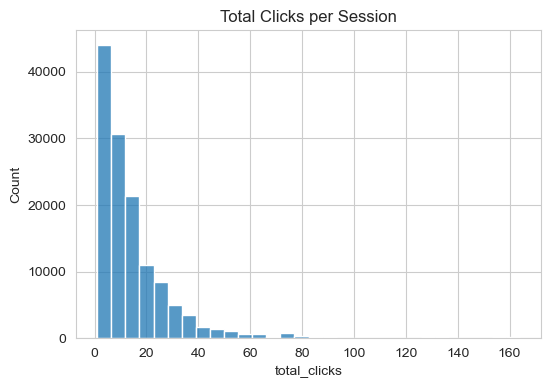

In [9]:
# 8. Feature Distribution
# Univariate – Total Clicks

plt.figure(figsize=(6,4))
sns.histplot(train_df['total_clicks'], bins=30)
plt.title("Total Clicks per Session")
plt.show()


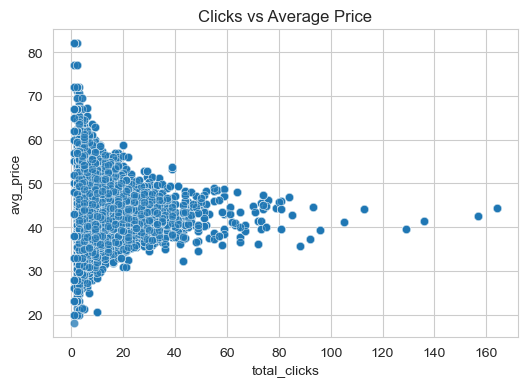

In [10]:
# Bivariate – Clicks vs Price

plt.figure(figsize=(6,4))
sns.scatterplot(x='total_clicks', y='avg_price', data=train_df, alpha=0.5)
plt.title("Clicks vs Average Price")
plt.show()


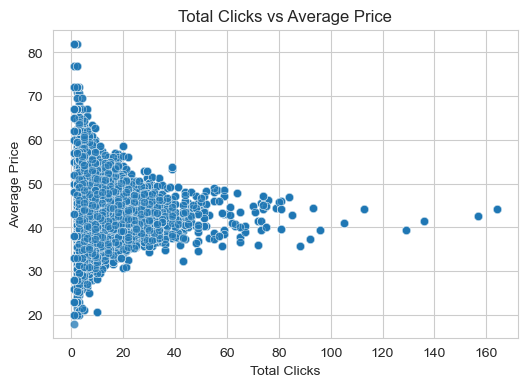

In [11]:
# BIVARIATE ANALYSIS (Engineered Features)
# Total Clicks vs Average Price

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='total_clicks',
    y='avg_price',
    data=train_df,
    alpha=0.5
)
plt.title("Total Clicks vs Average Price")
plt.xlabel("Total Clicks")
plt.ylabel("Average Price")
plt.show()


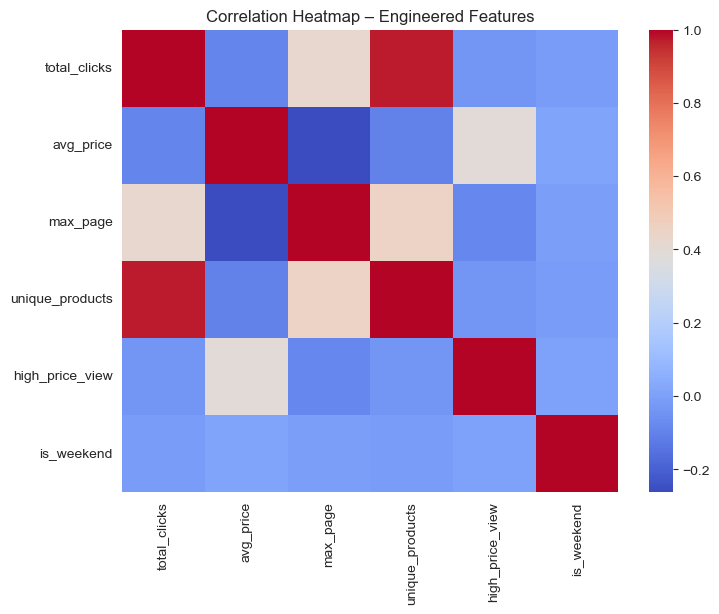

In [12]:
# MULTIVARIATE ANALYSIS (Engineered Features Only)

engineered_cols = [
    'total_clicks',
    'avg_price',
    'max_page',
    'unique_products',
    'high_price_view',
    'is_weekend'
]

plt.figure(figsize=(8,6))
sns.heatmap(train_df[engineered_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap – Engineered Features")
plt.show()


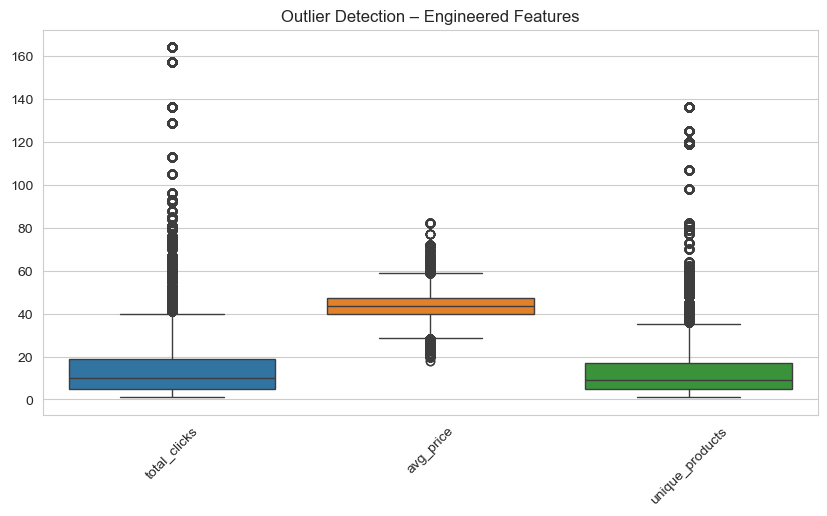

In [13]:
# 9. OUTLIER CHECK (Engineered Numerical Features)

plt.figure(figsize=(10,5))
sns.boxplot(data=train_df[['total_clicks','avg_price','unique_products']])
plt.xticks(rotation=45)
plt.title("Outlier Detection – Engineered Features")
plt.show()


In [14]:
# 10. Save Feature Engineered Data

train_df.to_csv('../data/train_featured.csv', index=False)
test_df.to_csv('../data/test_featured.csv', index=False)

print("✅ train_featured.csv and test_featured.csv saved successfully.")


✅ train_featured.csv and test_featured.csv saved successfully.
